In [20]:
import numpy as np
from typing import Optional, List

from initializers import initialize_weights
from activations import get_activation, get_activation_derivative
from losses import get_loss_function, get_loss_derivative, l2_regularization
from optimizers import get_optimizer


In [21]:
class DenseLayer:
    """Holds W, b, activation, and caches. Does NOT perform forward/backward."""
    def __init__(self, input_size, output_size, activation='relu',
                 weight_init='xavier', seed=None):

        self.W, self.b = initialize_weights(
            input_size,
            output_size,
            method=weight_init,
            seed=seed
        )

        self.activation = activation
        self.activation_cache = {
            'A_prev': None,
            'Z': None,
            'A': None
        }

        # Gradients
        self.dW = None
        self.db = None


In [26]:

class NeuralNetwork:
    # Fully-connected feedforward neural network implemented with NumPy
    # Supports: configurable layers, multiple activations, optimizers, L2 regularization
    
    def __init__(
        self,
        input_size: int,
        hidden_layers: List[int],
        output_size: int,
        activation: str = 'relu',
        output_activation: str = 'softmax',
        learning_rate: float = 0.01,
        optimizer: str = 'sgd',
        weight_init: str = 'xavier',
        l2_lambda: float = 0.0,
        random_seed: Optional[int] = None
    ):
        # Initialize network: create layers, set up optimizer, store hyperparameters
        self.layers = []
        input_dim = input_size

        # Create hidden layers
        for hidden_units in hidden_layers:
            layer = DenseLayer(
                input_size=input_dim,
                output_size=hidden_units,
                activation=activation,
                weight_init=weight_init,
                seed=random_seed
            )
            self.layers.append(layer)
            input_dim = hidden_units 

        # Output layer
        self.layers.append(DenseLayer(
            input_size=input_dim,
            output_size=output_size,
            activation=output_activation,
            weight_init=weight_init,
            seed=random_seed
        ))
        
        # Store hyperparameters
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.activation = activation
        self.output_activation = output_activation
        self.learning_rate = learning_rate
        self.optimizer_name = optimizer
        self.l2_lambda = l2_lambda
        
        # Initialize optimizer
        self.optimizer = get_optimizer(optimizer, learning_rate=learning_rate)
        
        # Store loss function (default to cross_entropy for classification)
        self.loss_function = 'cross_entropy'
        
        # Store last predictions and loss for debugging
        self.last_predictions = None
        self.last_loss = None
    
    
    # ------------------------------------------------------------------
    # FORWARD
    # ------------------------------------------------------------------

    def forward(self, X: np.ndarray) -> np.ndarray:

        A = X

        for layer in self.layers:

            # Cache previous activation
            layer.activation_cache['A_prev'] = A

            # Linear
            Z = A @ layer.W + layer.b
            layer.activation_cache['Z'] = Z

            # Activation
            act = get_activation(layer.activation)
            A = act(Z)

            # Cache activation
            layer.activation_cache['A'] = A

        return A

    # ------------------------------------------------------------------
    # BACKWARD
    # ------------------------------------------------------------------

    def backward(self, X: np.ndarray, y: np.ndarray, y_pred=None):

        if y_pred is None:
            y_pred = self.forward(X)

        loss_deriv_fn = get_loss_derivative(self.loss_function)
        dA = loss_deriv_fn(y_pred, y)

        # Backprop layers in reverse
        for layer in reversed(self.layers):

            Z = layer.activation_cache['Z']
            A_prev = layer.activation_cache['A_prev']

            # dZ = dA * activation'(Z)
            activation_grad = get_activation_derivative(layer.activation)
            dZ = dA * activation_grad(Z)

            # Gradients
            layer.dW = A_prev.T @ dZ
            layer.db = np.sum(dZ, axis=0)

            # L2 regularization
            if self.l2_lambda > 0:
                layer.dW += self.l2_lambda * layer.W

            # Next gradient
            dA = dZ @ layer.W.T

    # ------------------------------------------------------------------
    # UPDATE
    # ------------------------------------------------------------------

    def update_weights(self) -> None:
        # Update all weights and biases using the optimizer
        
        # Collect parameters and gradients from all layers
        params = {}
        grads = {}
        for i, layer in enumerate(self.layers):
            params[f'W{i+1}'] = layer.W
            params[f'b{i+1}'] = layer.b
            grads[f'W{i+1}'] = layer.dW
            grads[f'b{i+1}'] = layer.db
        
        # Apply optimizer update rule
        updated_params = self.optimizer.update(params, grads)
        
        # Update layer weights and biases with new values
        for i, layer in enumerate(self.layers):
            layer.W = updated_params[f'W{i+1}']
            layer.b = updated_params[f'b{i+1}']
    
    
    # ------------------------------------------------------------------
    # COMPUTE LOSS
    # ------------------------------------------------------------------

    def compute_loss(self, y_pred: np.ndarray, y_true: np.ndarray) -> float:
        # Compute total loss: data loss + L2 regularization
        # y_pred: predictions, y_true: true labels -> returns: scalar loss
        
        # Compute data loss (e.g., cross-entropy)
        loss_func = get_loss_function(self.loss_function)
        data_loss = loss_func(y_pred, y_true)
        
        # Add L2 regularization term if specified
        if self.l2_lambda > 0:
            weights = [layer.W for layer in self.layers]
            reg_loss = l2_regularization(weights, self.l2_lambda)
            total_loss = data_loss + reg_loss
        else:
            total_loss = data_loss
        
        return total_loss
    

    # ------------------------------------------------------------------
    # TRAINING STEP
    # ------------------------------------------------------------------

    def train_step(self, X_batch: np.ndarray, y_batch: np.ndarray) -> float:
        # One complete training step: forward -> backward -> update
        # Returns loss value for this batch
        
        # Forward pass: compute predictions
        y_pred = self.forward(X_batch)
        
        # Compute loss
        loss = self.compute_loss(y_pred, y_batch)
        
        # Backward pass: compute gradients (pass y_pred to avoid redundant forward)
        self.backward(X_batch, y_batch, y_pred=y_pred)
        
        # Update weights using computed gradients
        self.update_weights()
        
        # Store for debugging/monitoring
        self.last_predictions = y_pred
        self.last_loss = loss
        
        return loss

    # ------------------------------------------------------------------
    # PREDICT
    # ------------------------------------------------------------------

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Predict class labels: get probabilities and return argmax
        # X: (batch_size, input_size) -> returns: (batch_size,) class indices
        probabilities = self.predict_proba(X)
        predictions = np.argmax(probabilities, axis=1)
        return predictions
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # Get prediction probabilities (forward pass without training)
        # X: (batch_size, input_size) -> returns: (batch_size, output_size) probabilities
        probabilities = self.forward(X)
        return probabilities
    
    
    # ------------------------------------------------------------------
    # PARAMETERS
    # ------------------------------------------------------------------

    def get_params(self) -> dict:
        # Get all model parameters (weights and biases) as dictionary
        # Returns: {'W1': weights, 'b1': biases, 'W2': ..., ...}
        params = {}
        for i, layer in enumerate(self.layers):
            params[f'W{i+1}'] = layer.W.copy()
            params[f'b{i+1}'] = layer.b.copy()
        return params
    
    def set_params(self, params: dict) -> None:
        # Set model parameters from dictionary
        # params: {'W1': weights, 'b1': biases, 'W2': ..., ...}
        for i, layer in enumerate(self.layers):
            layer.W = params[f'W{i+1}'].copy()
            layer.b = params[f'b{i+1}'].copy()


## Samme tests, men skal slettes som next-step

In [27]:
# Creating data set

# A
a =[0, 0, 1, 1, 0, 0,
   0, 1, 0, 0, 1, 0,
   1, 1, 1, 1, 1, 1,
   1, 0, 0, 0, 0, 1,
   1, 0, 0, 0, 0, 1]
# B
b =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0]
# C
c =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 1, 1, 1, 0]

# Creating labels
y =[[1, 0, 0],
   [0, 1, 0],
   [0, 0, 1]]

# converting data and labels into numpy array
x =[np.array(a).reshape(1, 30), np.array(b).reshape(1, 30), 
                                np.array(c).reshape(1, 30)]
y = np.array(y)
# Printing data and labels
print(x, "\n\n", y)

[array([[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 1]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 0]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0]])] 

 [[1 0 0]
 [0 1 0]
 [0 0 1]]


In [34]:

input_dim = x[0].shape[1]   # -> 30 for your toy letters
hidden_dim = 10
output_dim = y.shape[1]     # -> 3 for your one-hot labels

model = NeuralNetwork(input_dim, [hidden_dim], output_dim)
print("input_dim:", input_dim, "output_dim:", output_dim)

input_dim: 30 output_dim: 3


epoch: 1 avg loss: 0.22141835842910026 acc: 77.85816415708997
epoch: 2 avg loss: 0.21994598554020536 acc: 78.00540144597946
epoch: 3 avg loss: 0.21847814631395587 acc: 78.1521853686044
epoch: 4 avg loss: 0.21701461894603688 acc: 78.2985381053963
epoch: 5 avg loss: 0.2155551921023372 acc: 78.44448078976627
epoch: 6 avg loss: 0.21409966455840104 acc: 78.5900335441599
epoch: 7 avg loss: 0.21264784486585767 acc: 78.73521551341423
epoch: 8 avg loss: 0.21144178237583486 acc: 78.85582176241651
epoch: 9 avg loss: 0.20995775282246695 acc: 79.0042247177533
epoch: 10 avg loss: 0.2085158168679017 acc: 79.14841831320983
epoch: 11 avg loss: 0.20707701555467792 acc: 79.29229844453221
epoch: 12 avg loss: 0.2059429097071361 acc: 79.40570902928638
epoch: 13 avg loss: 0.20441184659593561 acc: 79.55881534040644
epoch: 14 avg loss: 0.20298152987594206 acc: 79.70184701240579
epoch: 15 avg loss: 0.20154109624920727 acc: 79.84589037507928
epoch: 16 avg loss: 0.2004378836606688 acc: 79.95621163393312
epoch: 17

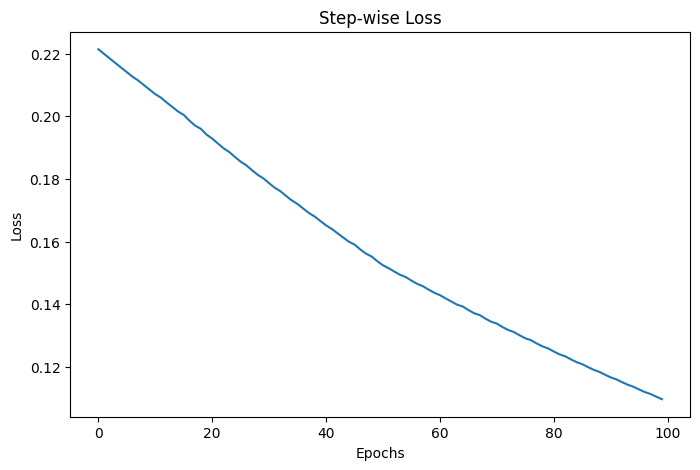

In [35]:
import matplotlib.pyplot as plt
learning_rate = 0.1

loss_fn = get_loss_function('mse')

num_epochs = 100
loss_values = []   # collect per-epoch average loss
acc = []

for j in range(num_epochs):
    l = []
    for i in range(len(x)):
        # single-sample forward
        out = model.forward(x[i])         # forward
        l.append(loss_fn(out, y[i]))                    # record loss
        model.backward(x[i], y[i])                      # compute gradients
        model.update_weights()                          # apply update

    epoch_loss = float(sum(l) / len(l))
    loss_values.append(epoch_loss)
    print("epoch:", j + 1, "avg loss:", epoch_loss, "acc:", (1 - epoch_loss) * 100)
    acc.append((1 - epoch_loss) * 100)

print("Training Complete")

step = range(len(loss_values))
fig, ax = plt.subplots(figsize=(8,5))
plt.plot(step, np.array(loss_values))
plt.title("Step-wise Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()